In [1]:
import xgboost, dask, distributed, sys

print("xgboost:", xgboost.__version__)
print("dask:", dask.__version__)
print("distributed:", distributed.__version__)
print("python:", sys.version)

xgboost: 2.1.4
dask: 2024.12.1
distributed: 2024.12.1
python: 3.11.12 (main, Apr  9 2025, 08:55:55) [GCC 13.3.0]


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from newutils.data.datasets import load_train_subset, add_lags
from newutils.other.helpers import init_context
from oldutils.types import TimeRange
from oldutils.datasets import ARTIFACTS_FOLDER

init_context()

In [4]:
HORIZON_HISTORY = TimeRange.YEAR
HORIZON_FORECAST = TimeRange.WEEK

COL_GAUGE_ID = "gauge_id"
TARGETS = ["q_mm_day"]

In [5]:
df = load_train_subset()

In [6]:
lags = range(1, HORIZON_HISTORY + 1)
lags_columns = ["prcp", "t_max", "t_min", "t_mean", "q_mm_day", "lvl_sm"]
df = add_lags(df, lags_columns, lags)

In [7]:
targets = []
df = add_lags(df, targets, range(1, HORIZON_FORECAST + 1), targets)
targets.extend(TARGETS)

In [8]:
df = df.dropna()

In [9]:
X = df.drop(columns=set(lags_columns + ["q_mm_day"] + ["date"]))
y = df[targets]
X_train, y_train = X, y

# Model

In [10]:
from dask.distributed import Client, LocalCluster, wait
import dask

# dask.config.set(scheduler="processes")

# from dask_cuda import LocalCUDACluster
import gc

# try:
#     client.close()
#     cluster.close()
#     print("Delete")
# except NameError:
#     print("Nothing")
#     pass
# gc.collect()

# cluster = LocalCluster(dashboard_address=":8789", asynchronous=True)
# # cluster = LocalCUDACluster(CUDA_VISIBLE_DEVICES="0", n_workers=1, dashboard_address=":8789")
# client = cluster.get_client()
# client = Client()

# print(cluster)
# print(client)

In [ ]:
import dask.array as da
import pandas as pd
import numpy as np
import dask.dataframe as dd
import xgboost.dask as dxgb
import warnings

params = {
    "objective": "reg:squarederror",
    "max_depth": 3,
    "eta": 0.1,
    "tree_method": "hist",
}


# async def main():
def main():
    try:
        client.close()
        cluster.close()
        print("Deleted previous client and cluster")
    except NameError:
        print("Nothing to delete")
    gc.collect()

    # 3. Start cluster & client in async mode
    # async
    with LocalCluster(
        dashboard_address=":8789",
        asynchronous=False,
        n_workers=2,
        threads_per_worker=1,
        memory_limit="2 GiB",
        processes=True,
    ) as cluster:
        # async
        with Client(cluster, asynchronous=False) as client:
            print("Dask client running in async mode:", client)
            warnings.filterwarnings("ignore")

            # 5. Build the DaskDMatrix and train
            # X_trainp, y_trainp = await client.persist([X_train, y_train])
            print("Prepare datasets...")
            with warnings.catch_warnings(record=True) as caught_warnings:
                X_trainp, y_trainp = client.persist([X_train, y_train])
                wait([X_trainp, y_trainp])
            print("Create train set...")
            dtrain = dxgb.DaskDMatrix(client, X_trainp, y_trainp)
            print("Train model...")
            # booster, training_history = await dxgb.train(
            results = dxgb.train(client, params, dtrain, num_boost_round=10)
            results["booster"].save_model(ARTIFACTS_FOLDER / "test_save.json")

            print("Training metrics and booster information:")
            print(results["history"])
            print(results["booster"])
    return results


result = main()
print(result)

Nothing to delete
Dask client running in async mode: <Client: 'tcp://127.0.0.1:42579' processes=2 threads=2, memory=4.00 GiB>
Prepare datasets...


/home/khuzin/Projects/2025-Project-188/code/src/newutils/data/datasets.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pdf[_gen_lag_name(column, lag)] = pdf[column].shift(lag)
/home/khuzin/Projects/2025-Project-188/code/src/newutils/data/datasets.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pdf[_gen_lag_name(column, lag)] = pdf[column].shift(lag)
/home/khuzin/Projects/2025-Project-188/code/src/newutils/data/datasets.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fr

Create train set...
Train model...


[11:09:35] Task [xgboost.dask-0]:tcp://127.0.0.1:33475 got rank 0
[11:09:35] Task [xgboost.dask-1]:tcp://127.0.0.1:38609 got rank 1
2025-05-04 11:09:40,422 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 1.59 GiB -- Worker memory limit: 2.00 GiB
2025-05-04 11:09:40,813 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 1.60 GiB -- Worker memory limit: 2.00 GiB
2025-05-04 11:09:42,213 - distributed.worker.memory - WARNING - Worker is at 68% memory usage. Resuming worker. Process memory: 1.37 GiB -- Worker memory limit: 2.00 GiB


Training metrics and booster information:
{}
None


In [13]:
X_test = X.get_partition(0).compute()

In [14]:
import xgboost as xgb
import shap

booster = xgb.Booster()

booster.load_model(ARTIFACTS_FOLDER / "test_save.json")

# dtest = xgb.DMatrix(data=X_train)
# preds = booster.predict(dtest)

explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test)

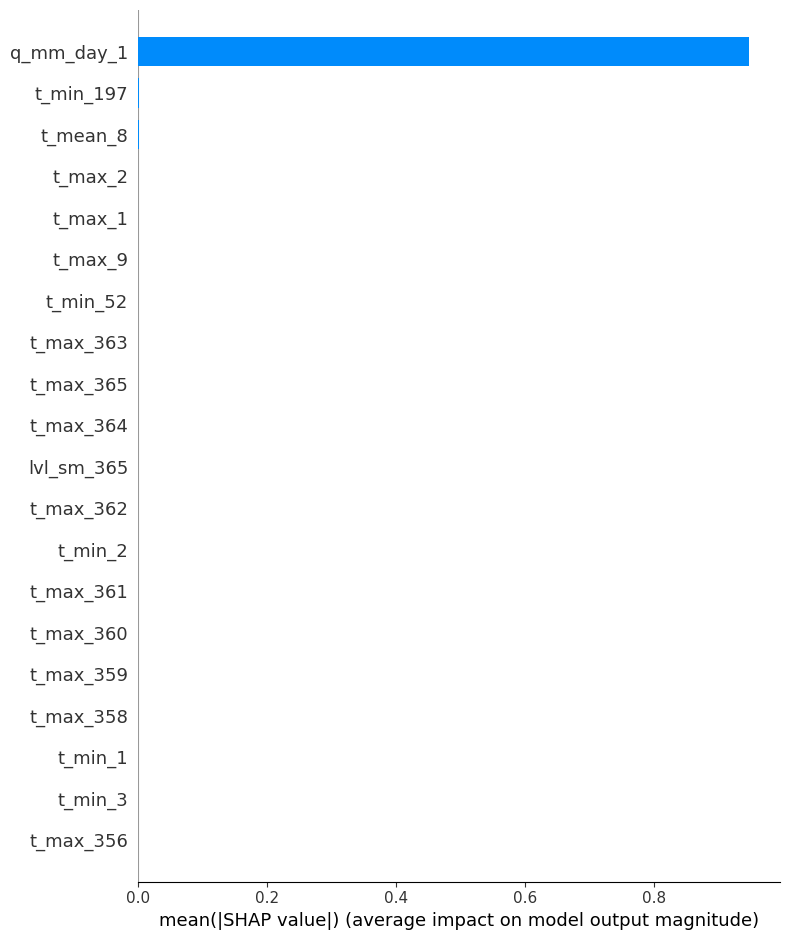

In [15]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

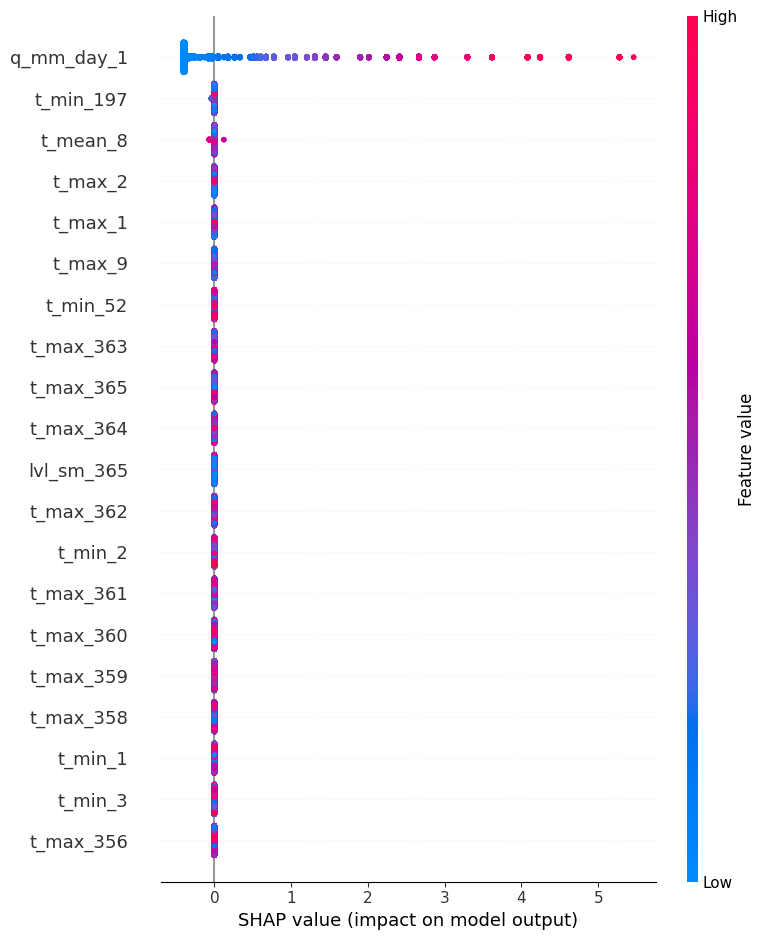

In [16]:
shap.summary_plot(shap_values, X_test)

In [ ]:
import gc

client.close()
cluster.close()
gc.collect()